In [1]:
import sys
from pathlib import Path

ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from src.models.evaluate import regression_metrics
from src.config import DATASETS, PROCESSED_DIR, MODELS_DIR, USEFUL_SENSORS

sns.set_theme(style="whitegrid")

In [2]:
with open(PROCESSED_DIR / "metadata.json") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]

processed = {}
for ds_id in DATASETS:
    train = pd.read_parquet(PROCESSED_DIR / f"train_{ds_id}.parquet")
    test = pd.read_parquet(PROCESSED_DIR / f"test_{ds_id}.parquet")
    processed[ds_id] = {"train": train, "test": test}

ds_id = "FD001"
train = processed[ds_id]["train"]
test = processed[ds_id]["test"]

exclude = {"unit_id", "cycle", "rul", "label"}
available_cols = [c for c in train.columns if c not in exclude and c in test.columns]

X_train = train[available_cols]
X_test = test[available_cols]
y_test = test["rul"].values

print(f"Features: {len(available_cols)}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Features: 16
X_train: (20631, 16) | X_test: (100, 16)


In [3]:
with open(MODELS_DIR / "random_forest_reg_FD001.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open(MODELS_DIR / "xgboost_reg_FD001.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open(MODELS_DIR / "xgboost_clf_FD001.pkl", "rb") as f:
    xgb_clf = pickle.load(f)

print("✓ Modelos cargados")

✓ Modelos cargados


In [4]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer(X_test)

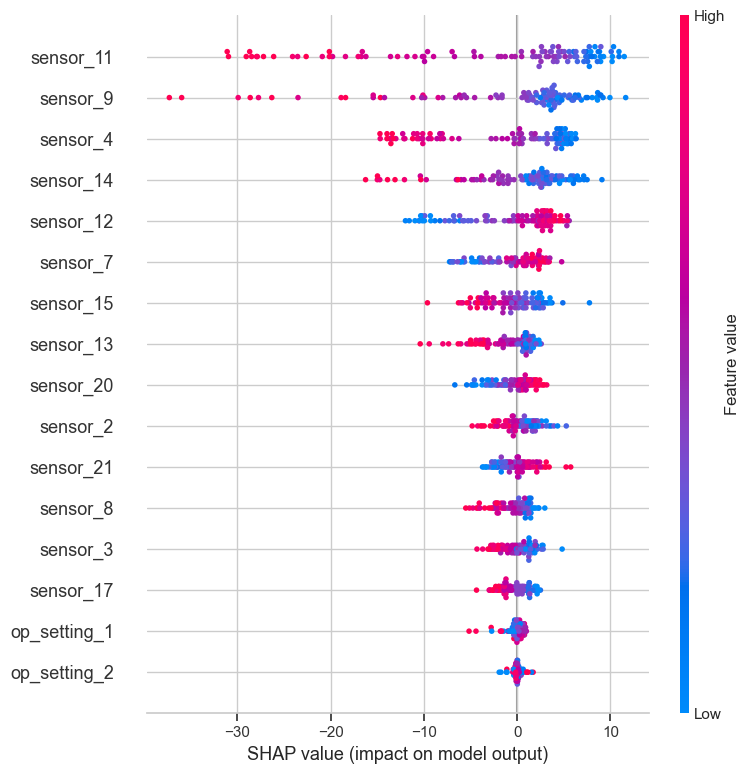

In [5]:
shap.summary_plot(xgb_shap_values, X_test, show=True)

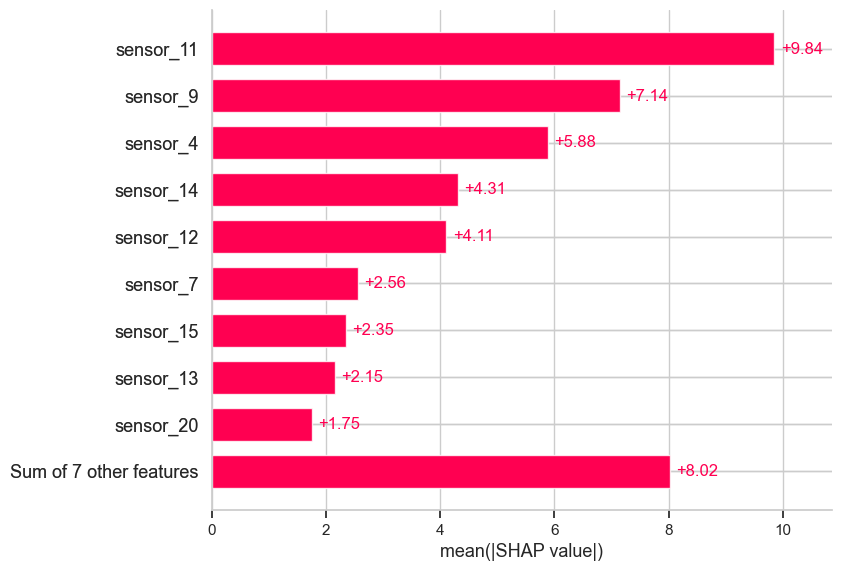

In [6]:
shap.plots.bar(xgb_shap_values, show=True)

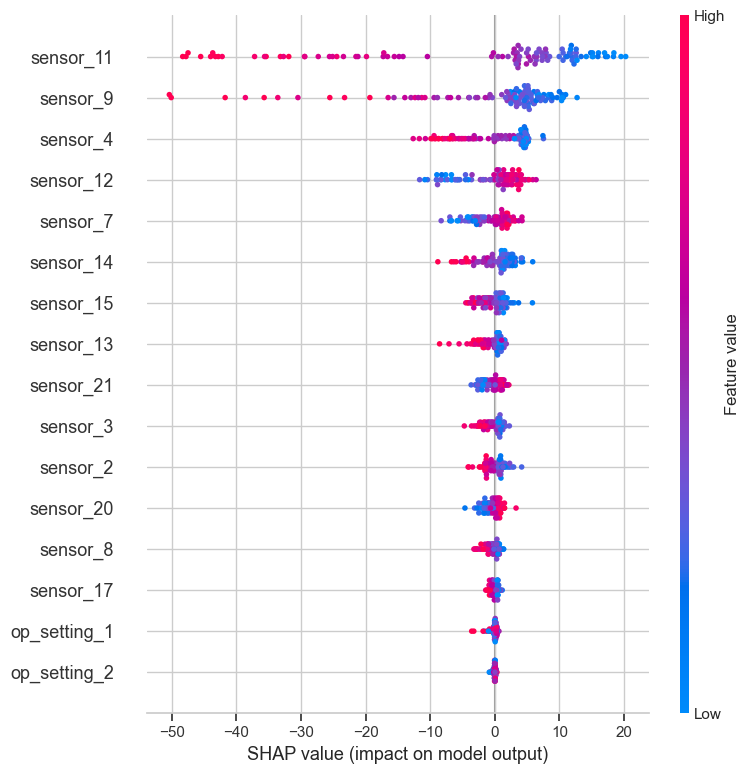

In [7]:
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer(X_test)

shap.summary_plot(rf_shap_values, X_test, show=True)

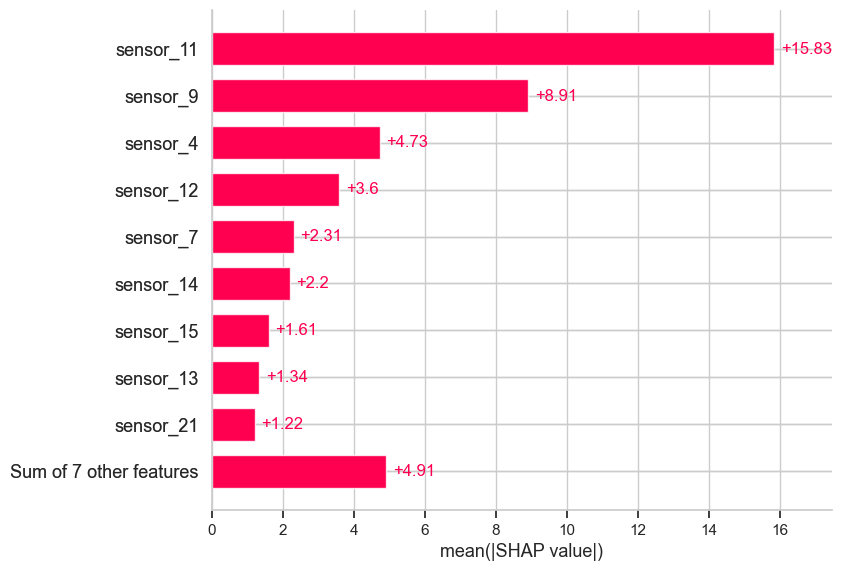

In [8]:
shap.plots.bar(rf_shap_values, show=True)

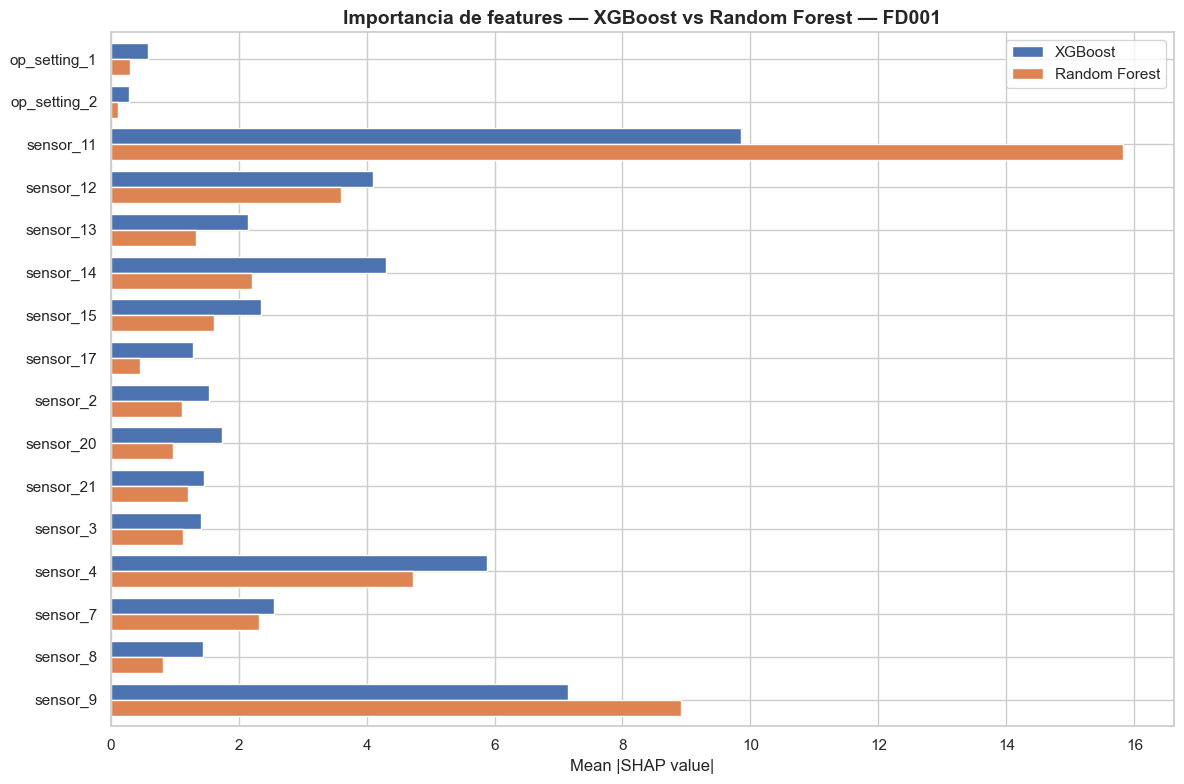

In [9]:
xgb_importance = pd.Series(
    np.abs(xgb_shap_values.values).mean(axis=0),
    index=available_cols,
    name="XGBoost",
).sort_values(ascending=False)

rf_importance = pd.Series(
    np.abs(rf_shap_values.values).mean(axis=0),
    index=available_cols,
    name="Random Forest",
).sort_values(ascending=False)

importance_df = pd.DataFrame({"XGBoost": xgb_importance, "Random Forest": rf_importance})

fig, ax = plt.subplots(figsize=(12, 8))
importance_df.plot(kind="barh", ax=ax, width=0.75, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Importancia de features — XGBoost vs Random Forest — FD001", fontsize=14, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

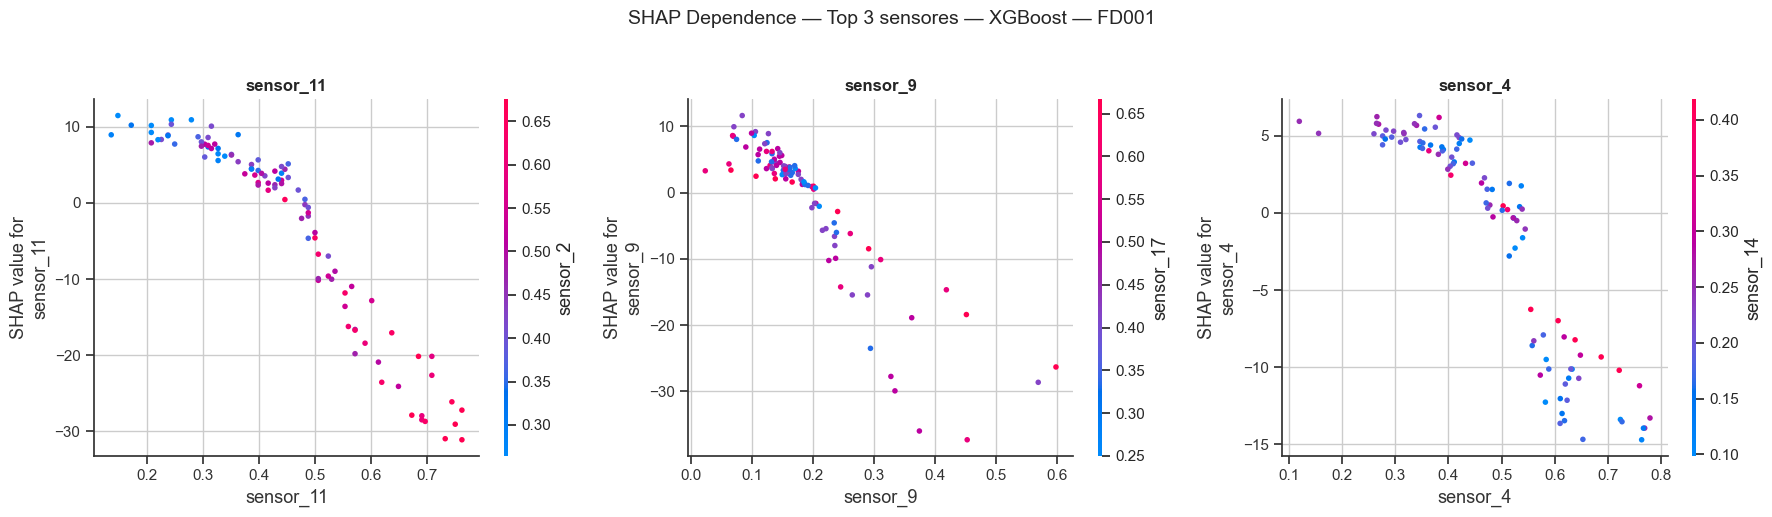

In [10]:
top3 = xgb_importance.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, sensor in enumerate(top3):
    shap.dependence_plot(sensor, xgb_shap_values.values, X_test, ax=axes[i], show=False)
    axes[i].set_title(f"{sensor}", fontsize=12, fontweight="bold")

plt.suptitle("SHAP Dependence — Top 3 sensores — XGBoost — FD001", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

Motor 1 — RUL real: 112


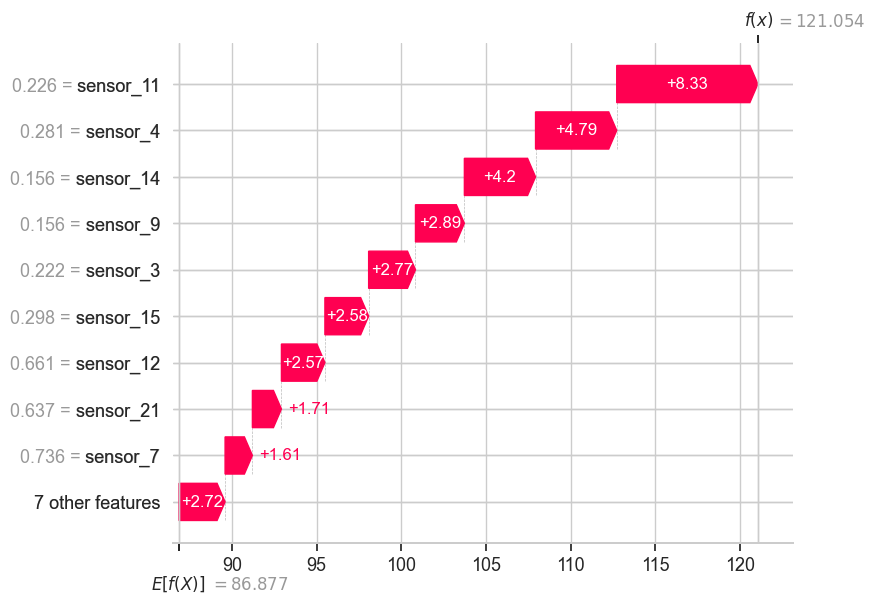

In [11]:
motor_idx = 0
print(f"Motor {test.iloc[motor_idx]['unit_id']:.0f} — RUL real: {y_test[motor_idx]}")
shap.waterfall_plot(xgb_shap_values[motor_idx], show=True)

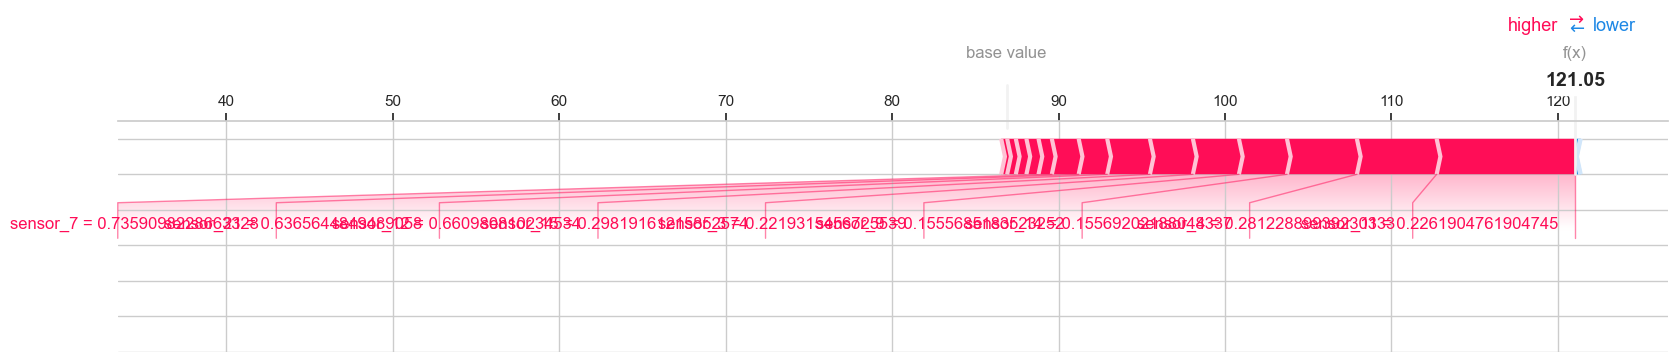

In [12]:
shap.force_plot(xgb_explainer.expected_value, xgb_shap_values.values[motor_idx], X_test.iloc[motor_idx], matplotlib=True)
plt.show()

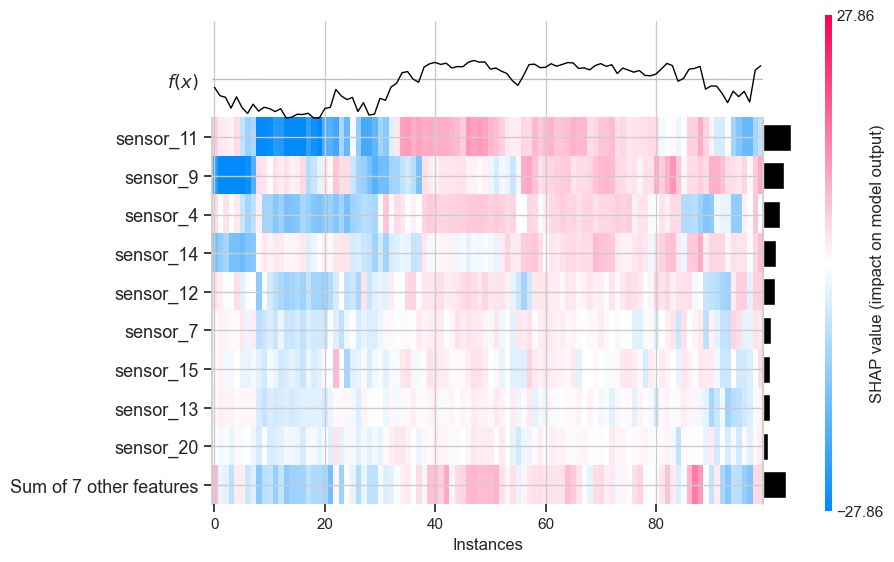

<Axes: xlabel='Instances'>

In [13]:
shap.plots.heatmap(xgb_shap_values, show=True)

✓ FD001 completado
✓ FD002 completado
✓ FD003 completado
✓ FD004 completado


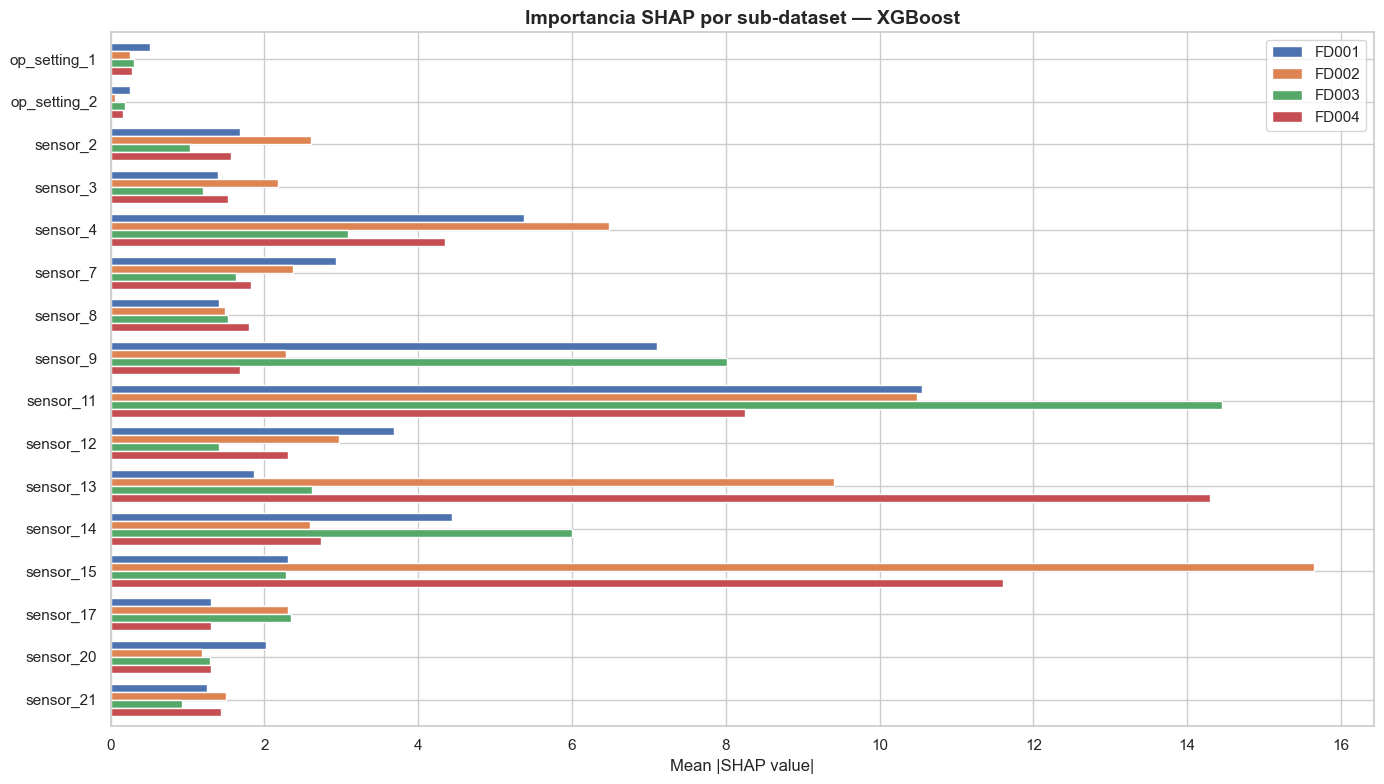

In [14]:
from xgboost import XGBRegressor
from src.config import RANDOM_STATE

shap_by_dataset = {}

for ds_id in DATASETS:
    tr = processed[ds_id]["train"]
    te = processed[ds_id]["test"]
    avail = [c for c in tr.columns if c not in exclude and c in te.columns]

    X_tr = tr[avail].values
    y_tr = tr["rul"].values
    X_te = te[avail]

    model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_tr, y_tr)

    explainer = shap.TreeExplainer(model)
    sv = explainer(X_te)
    shap_by_dataset[ds_id] = pd.Series(np.abs(sv.values).mean(axis=0), index=avail)
    print(f"✓ {ds_id} completado")

shap_cross = pd.DataFrame(shap_by_dataset)

fig, ax = plt.subplots(figsize=(14, 8))
shap_cross.plot(kind="barh", ax=ax, width=0.75, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Importancia SHAP por sub-dataset — XGBoost", fontsize=14, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
print("=" * 60)
print("  TOP 5 SENSORES POR DATASET")
print("=" * 60)
for ds_id in DATASETS:
    top5 = shap_cross[ds_id].sort_values(ascending=False).head(5)
    print(f"\n  {ds_id}:")
    for sensor, val in top5.items():
        print(f"    {sensor}: {val:.4f}")
print("=" * 60)

  TOP 5 SENSORES POR DATASET

  FD001:
    sensor_11: 10.5460
    sensor_9: 7.1092
    sensor_4: 5.3754
    sensor_14: 4.4448
    sensor_12: 3.6827

  FD002:
    sensor_15: 15.6454
    sensor_11: 10.4914
    sensor_13: 9.4027
    sensor_4: 6.4813
    sensor_12: 2.9718

  FD003:
    sensor_11: 14.4550
    sensor_9: 8.0121
    sensor_14: 5.9997
    sensor_4: 3.0820
    sensor_13: 2.6155

  FD004:
    sensor_13: 14.2913
    sensor_15: 11.6076
    sensor_11: 8.2448
    sensor_4: 4.3464
    sensor_14: 2.7371


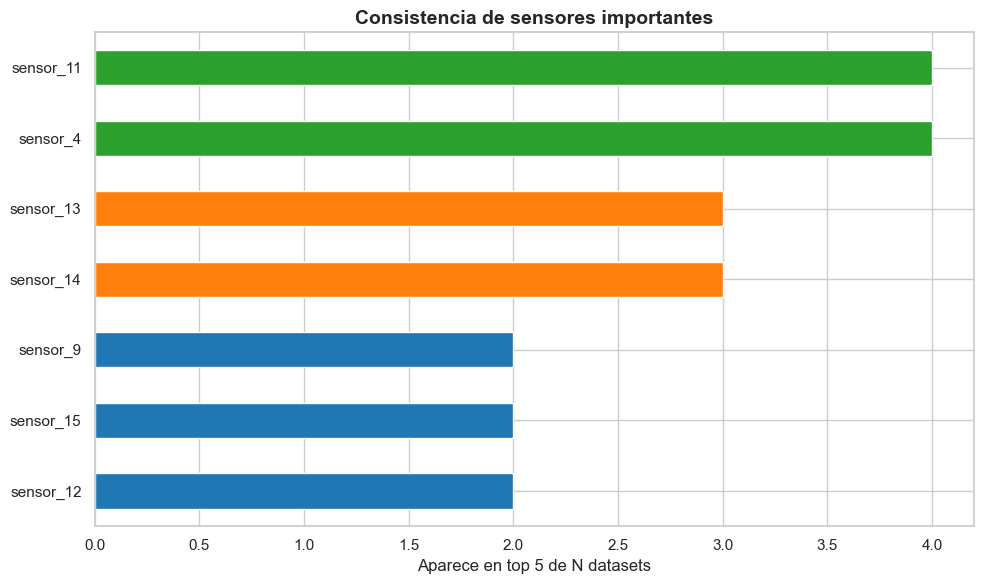

In [16]:
top5_per_ds = {}
for ds_id in DATASETS:
    top5_per_ds[ds_id] = set(shap_cross[ds_id].sort_values(ascending=False).head(5).index)

all_top5 = set()
for s in top5_per_ds.values():
    all_top5 = all_top5.union(s)

consistency = {}
for sensor in all_top5:
    count = sum(1 for ds_id in DATASETS if sensor in top5_per_ds[ds_id])
    consistency[sensor] = count

consistency_df = pd.Series(consistency).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ca02c" if v == 4 else "#ff7f0e" if v == 3 else "#1f77b4" if v == 2 else "#d62728" for v in consistency_df.values]
consistency_df.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_xlabel("Aparece en top 5 de N datasets")
ax.set_title("Consistencia de sensores importantes", fontsize=14, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

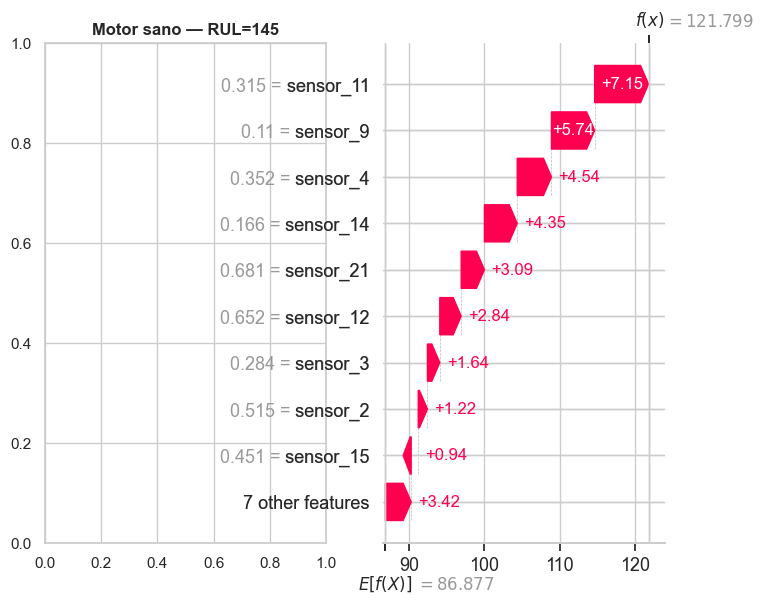

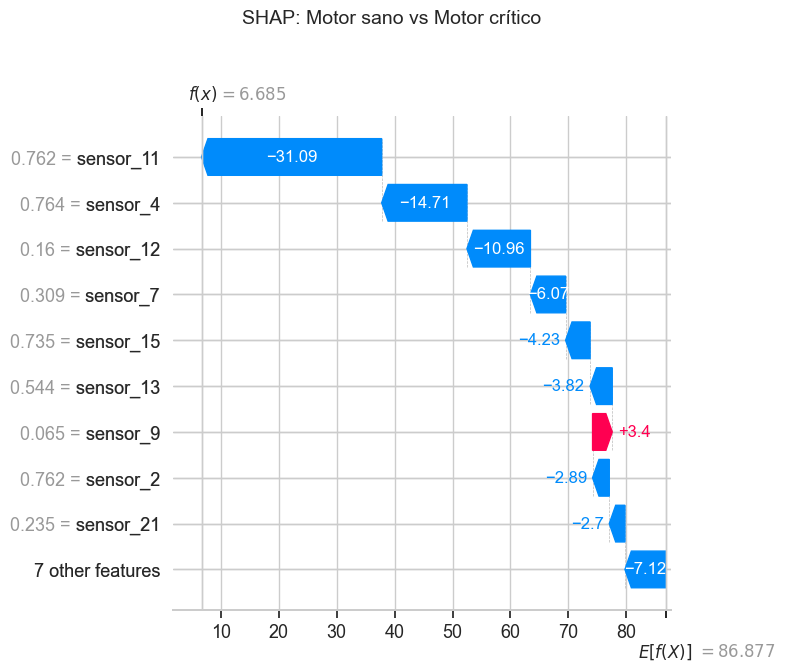

In [17]:
sano_idx = y_test.argmax()
critico_idx = y_test.argmin()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

shap.waterfall_plot(xgb_shap_values[sano_idx], show=False)
axes[0].set_title(f"Motor sano — RUL={y_test[sano_idx]}", fontsize=12, fontweight="bold")

plt.figure()
shap.waterfall_plot(xgb_shap_values[critico_idx], show=False)

plt.suptitle("SHAP: Motor sano vs Motor crítico", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [18]:
print("=" * 60)
print("  RESUMEN SHAP ANALYSIS")
print("=" * 60)
print(f"\n  Top 5 sensores (XGBoost, FD001):")
for s, v in xgb_importance.head(5).items():
    print(f"    {s}: {v:.4f}")
print(f"\n  Top 5 sensores (Random Forest, FD001):")
for s, v in rf_importance.head(5).items():
    print(f"    {s}: {v:.4f}")
print(f"\n  Sensores consistentes (top 5 en 4/4 datasets):")
for s, v in consistency_df.items():
    if v == 4:
        print(f"    {s}")
print(f"\n  SHAP revela qué sensores impulsan las predicciones")
print(f"  Los sensores más importantes son consistentes entre modelos")
print(f"  Dependence plots muestran relaciones no-lineales")
print("=" * 60)

  RESUMEN SHAP ANALYSIS

  Top 5 sensores (XGBoost, FD001):
    sensor_11: 9.8450
    sensor_9: 7.1427
    sensor_4: 5.8827
    sensor_14: 4.3064
    sensor_12: 4.1080

  Top 5 sensores (Random Forest, FD001):
    sensor_11: 15.8271
    sensor_9: 8.9139
    sensor_4: 4.7320
    sensor_12: 3.5961
    sensor_7: 2.3144

  Sensores consistentes (top 5 en 4/4 datasets):
    sensor_11
    sensor_4

  SHAP revela qué sensores impulsan las predicciones
  Los sensores más importantes son consistentes entre modelos
  Dependence plots muestran relaciones no-lineales


In [2]:
import json

with open("../data/processed/optuna_results.json") as f:
    optuna_data = json.load(f)

for key in sorted(optuna_data.keys()):
    if key.startswith(("lstm_", "gru_", "tcn_", "transformer_")) and "result" not in key:
        print(f"\n{key}:")
        print(f"  best_rmse: {optuna_data[key]['best_rmse']:.2f}")
        for k, v in optuna_data[key]['best_params'].items():
            print(f"  {k}: {v}")


gru_FD001:
  best_rmse: 12.22
  hidden_size: 128
  num_layers: 3
  dropout: 0.4
  lr: 0.0044106771579938715
  weight_decay: 7.579756671974912e-05
  batch_size: 32

gru_FD002:
  best_rmse: 11.24
  hidden_size: 64
  num_layers: 3
  dropout: 0.45
  lr: 0.0002640133605265578
  weight_decay: 0.00012325397062393434
  batch_size: 32

gru_FD003:
  best_rmse: 12.25
  hidden_size: 128
  num_layers: 2
  dropout: 0.30000000000000004
  lr: 0.002934384366941891
  weight_decay: 2.4869644268195842e-05
  batch_size: 64

gru_FD004:
  best_rmse: 15.67
  hidden_size: 192
  num_layers: 1
  dropout: 0.5
  lr: 0.0008833230360997906
  weight_decay: 0.00028604533294673666
  batch_size: 128

lstm_FD001:
  best_rmse: 12.54
  hidden_size: 192
  num_layers: 3
  dropout: 0.25
  lr: 0.00017923384499941508
  weight_decay: 0.00044228119636054234
  batch_size: 32

lstm_FD002:
  best_rmse: 10.76
  hidden_size: 64
  num_layers: 1
  dropout: 0.2
  lr: 0.002944227020060717
  weight_decay: 0.00018379666359595058
  batch_si

In [3]:
import torch
import json

with open("../data/processed/optuna_results.json") as f:
    optuna_data = json.load(f)

# Verificar un modelo
state = torch.load("../models/lstm_optuna_FD001.pt", map_location="cpu", weights_only=False)
print("Keys:", list(state.keys())[:5])
print("Total keys:", len(state.keys()))

Keys: ['rnn.weight_ih_l0', 'rnn.weight_hh_l0', 'rnn.bias_ih_l0', 'rnn.bias_hh_l0', 'rnn.weight_ih_l1']
Total keys: 21
